# Assignment 2

## PCA and eigendecomposition

Author: Samuel Fredric Berg

Student ID: sb224sc

Date: 2026-04-14

Course: Deep Machine Learning 4DT908

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sympy import Matrix

### Generate bi-variate normal random numbers

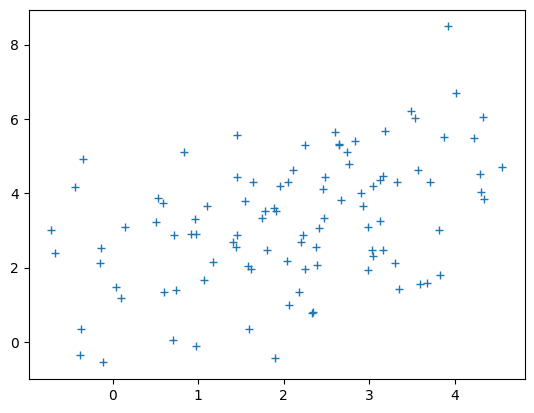

In [2]:
mu = [2, 3]
cov = [[2, 1.5], [1.5, 4]]

np.random.seed(42)
R = np.random.multivariate_normal(mu, cov, 100)

plt.plot(R[:, 0], R[:, 1], "+")
plt.show()

#### Check variance and correlation

In [3]:
sample_cov = np.cov(R, rowvar=False)
cor = np.corrcoef(R, rowvar=False)

print("Sample covariance:\n", sample_cov)
print("\nCorrelation:\n", cor)

Sample covariance:
 [[1.76781403 1.00496726]
 [1.00496726 2.94842117]]

Correlation:
 [[1.         0.44018867]
 [0.44018867 1.        ]]


#### Double check corr

In [4]:
print(1.00496726 / (1.76781403**0.5 * 2.94842117**0.5))

0.4401886749018094


### Perform PCA on the bi-variate normal random numbers

In [5]:
pca = PCA()
pca.fit(R)

loading_vector = pca.components_.T

latent = pca.explained_variance_

score = pca.transform(R)

variability_explained = pca.explained_variance_ratio_ * 100

print("Loading vectors:\n", loading_vector)
print("\nVariance explained:\n", variability_explained)

Loading vectors:
 [[ 0.4967515   0.86789282]
 [ 0.86789282 -0.4967515 ]]

Variance explained:
 [74.71275573 25.28724427]


#### Check correlation

In [6]:
print(np.corrcoef(score, rowvar=False))

[[1.00000000e+00 6.04528708e-16]
 [6.04528708e-16 1.00000000e+00]]


In [7]:
print("PC1:", np.linalg.norm(loading_vector[:, 0]))
print("PC2:", np.linalg.norm(loading_vector[:, 1]))
print("Dot prod:", np.dot(loading_vector[:, 0], loading_vector[:, 1]))

PC1: 1.0
PC2: 1.0
Dot prod: 0.0


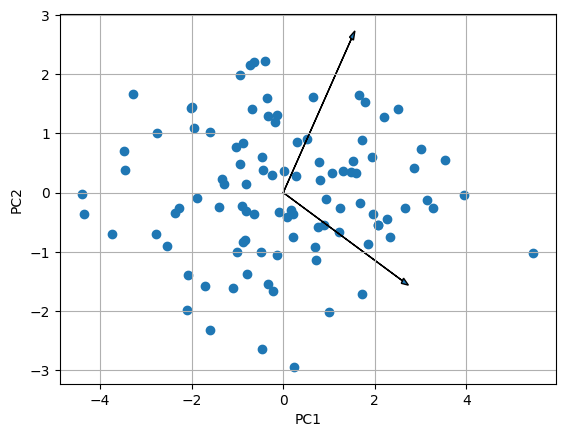

In [8]:
plt.scatter(score[:, 0], score[:, 1])
plt.arrow(0, 0, loading_vector[0, 0] * 3, loading_vector[0, 1] * 3, head_width=0.1)
plt.arrow(0, 0, loading_vector[1, 0] * 3, loading_vector[1, 1] * 3, head_width=0.1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

### Perform PCA step-by-step

In [ ]:
data = R
data[:, 0] = (R[:, 0] - np.mean(R[:, 0])) / np.sqrt(2.0479)
data[:, 1] = (R[:, 1] - np.mean(R[:, 1])) / np.sqrt(4.2666)

cov = np.cov(data, rowvar=False)

print(cov)

[[0.8632326  0.33998251]
 [0.33998251 0.69104701]]


In [ ]:
eigenvals, eigenvectors = np.linalg.eig(cov)
print("eigenvectors\n", eigenvectors)
print("eigenvalues\n", eigenvals)

eigenvectors
 [[ 0.78913841 -0.61421541]
 [ 0.61421541  0.78913841]]
eigenvalues
 [1.12785347 0.42642614]


#### Check eigenvalues

In [ ]:
print(cov @ eigenvectors[:, 0] - eigenvals[0] * eigenvectors[:, 0])
print(cov @ eigenvectors[:, 1] - eigenvals[1] * eigenvectors[:, 1])

[0. 0.]
[ 5.55111512e-17 -5.55111512e-17]


In [12]:
print(np.linalg.norm(eigenvectors[:, 0]))
print(np.linalg.norm(eigenvectors[:, 1]))
print(np.dot(eigenvectors[:, 0], eigenvectors[:, 1]))

1.0
1.0
0.0


In [13]:
score = data @ eigenvectors
print(np.corrcoef(score, rowvar=False))

[[ 1.00000000e+00 -1.83805379e-16]
 [-1.83805379e-16  1.00000000e+00]]


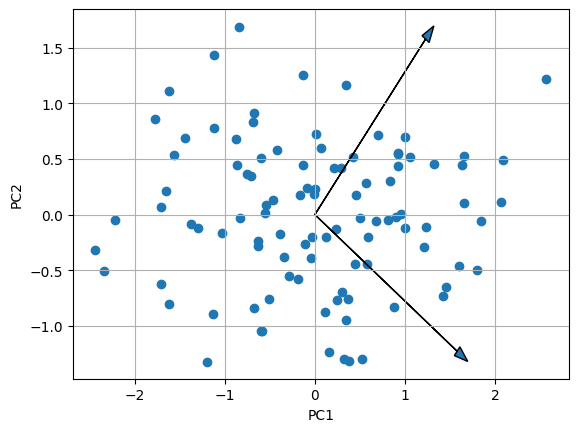

In [14]:
plt.scatter(score[:, 0], score[:, 1])
plt.arrow(0, 0, eigenvectors[0, 0] * 2, eigenvectors[0, 1] * 2, head_width=0.1)
plt.arrow(0, 0, eigenvectors[1, 0] * 2, eigenvectors[1, 1] * 2, head_width=0.1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [15]:
variances = np.var(score, axis=0)
print("Variances:", variances)
print("Explained variance ratio:", variances / sum(variances))

Variances: [1.11657493 0.42216188]
Explained variance ratio: [0.72564387 0.27435613]


Eigenvectors can be negated, probably why my arrows are pointing right while they are pointing up in the matlab example, below is the fixed version

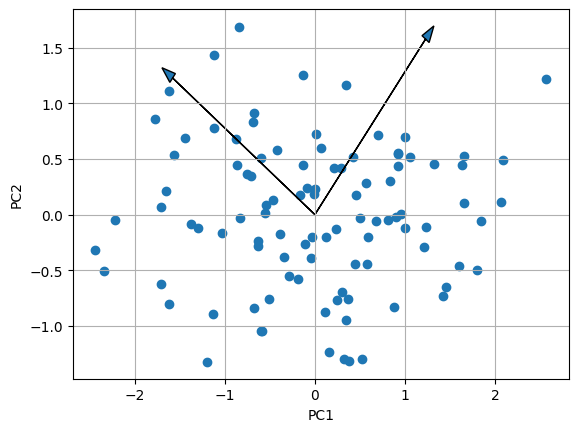

In [19]:
plt.scatter(score[:, 0], score[:, 1])
plt.arrow(0, 0, -eigenvectors[0, 0] * 2, -eigenvectors[0, 1] * 2, head_width=0.1)
plt.arrow(0, 0, eigenvectors[1, 0] * 2, eigenvectors[1, 1] * 2, head_width=0.1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [ ]:
print("Covariance matrix\n", cov)
a = 1
b = -cov[0, 0] - cov[1, 1]
c = cov[0, 0] * cov[1, 1] - cov[0, 1] * cov[1, 0]

eigenvalues = np.roots([a, b, c])
print("Eigenvalues\n", eigenvalues)

Covariance matrix
 [[0.8632326  0.33998251]
 [0.33998251 0.69104701]]
Eigenvalues
 [1.12785347 0.42642614]


In [ ]:
lambda1 = np.diag([eigenvalues[0], eigenvalues[0]])
print("lambda 1\n", lambda1)
char1 = cov - lambda1
print(np.linalg.det(char1))

lambda2 = np.diag([eigenvalues[1], eigenvalues[1]])
char2 = cov - lambda2
print(np.linalg.det(char2))

lambda 1
 [[1.12785347 0.        ]
 [0.         1.12785347]]
1.6985538414009587e-16
4.8495258750783945e-17


In [ ]:
A1 = cov - lambda1

print("A1:\n", A1)
print("Rank A1:", np.linalg.matrix_rank(A1))
print("Det A1:", np.linalg.det(A1))
rref = np.array(Matrix(np.round(A1, 5)).rref()[0]).astype(np.float64)
print("RREF A1:\n", rref)

A1:
 [[-0.26462087  0.33998251]
 [ 0.33998251 -0.43680646]]
Rank A1: 1
Det A1: 1.6985538414009587e-16
RREF A1:
 [[1. 0.]
 [0. 1.]]


In [23]:
v1 = np.array([-rref[0, 1], 1])
print("Eigenvector 1:", v1 / np.linalg.norm(v1))

Eigenvector 1: [-0.  1.]


In [ ]:
A2 = cov - lambda2
rref2 = np.array(Matrix(np.round(A2, 5)).rref()[0]).astype(np.float64)
v2 = np.array([-rref2[0, 1], 1])
print("Eigenvector 2:", v2 / np.linalg.norm(v2))

Eigenvector 2: [-0.  1.]
